Copyright (c) 2025 Data Charmers Pty Ltd. All rights reserved. Please do not distribute.

# Interpolating geospatial data on a grid

This chapter / notebook shows you how you can interpolate gridded geospatial data using SciPy and some ways to visualize the resulting interpolated data on maps

## Example: an interpolated density plot

The first example is of the cholera outbreak in London in 1854. Fortunately due to the work of a local doctor John Snow a major epidemic was averted through his convincing the local aldermen to remove the handle of the Broad Street pump - the source of the infection. The famous map, a section of which is show below, shows the location of the pump along side victims of the disease.

![](extras/snow_map_subset.png)

We might want to visualise the data. We could look at the locations of the victims of the disease as discrete points, but it would be nicer to see a surface to show where the presence of victims was more likely. One method of this is aggregating nearby points and interpolating a gridded surface.

### Data preparation

First, extracting the data:

In [1]:
%matplotlib inline

import pandas as pd

deaths = pd.read_csv('/Data/spatial/JohnSnow/victims.csv')
deaths[:3]

,x,y,num_cases
0,529163.243101,181014.977681,1.0
1,529166.497133,180780.299355,3.0
2,529173.292538,180790.641817,1.0


The x and y coordinates are the location of a point of data. We might firstly want to group nearby data together to have a better idea of the number of cases in any one location. The units themselves are in metres, so if we round to the nearest 50 metres we can then use a groupby in pandas to aggregate the data.

**Note** to aggregate to 50 metres, multiply the x and y by 2, round to the nearest 100, then divide by 2 to get the result.

In [2]:
rounded_locations = (
    (deaths[['x', 'y']] * 2).round(-2) / 2
).astype(
    int
).rename(
    columns={'x': 'x_round', 'y': 'y_round'}
)

deaths = deaths.join(rounded_locations)
deaths[:3]

,x,y,num_cases,x_round,y_round
0,529163.243101,181014.977681,1.0,529150,181000
1,529166.497133,180780.299355,3.0,529150,180800
2,529173.292538,180790.641817,1.0,529150,180800


In [3]:
merged_deaths = deaths.groupby(['x_round', 'y_round'])[['num_cases']].sum().reset_index()
merged_deaths[:3]

,x_round,y_round,num_cases
0,529150,180800,4.0
1,529150,181000,1.0
2,529200,180750,1.0


In [4]:
len(merged_deaths)

68

There are still 68 points but importantly we've aggregated lots of low scoring points in close proximity into larger values.

## Gridded interpolation with SciPy

The `scipy.interpolate` module hasa a `griddata` function which, given locations in $n$ dimensions, will interpolate data across a surface using one of three methods: nearest neighbour, linear interpolation or a cubic spline.

Given that we have locations in x and y where our data is stored along with the values to interpolate, we now require a continuous region across which to interpolate the data. The easiest way to get this is via the NumPy `meshgrid` function:

In [5]:
import numpy as np

xmax, ymax = merged_deaths[['x_round', 'y_round']].max() + 10.0
xmin, ymin = merged_deaths[['x_round', 'y_round']].min() - 10.0

In this case we will interpolate over a square grid of 1000 cells by 1000 cells:

In [6]:
grid_x, grid_y = np.meshgrid(np.linspace(xmin, xmax, 1000), np.linspace(ymin, ymax, 1000))

And we can interpolate the data to the locations from the meshgrid. We'll use a cubic spline which will show us a continuous surface:

In [7]:
from scipy.interpolate import griddata

surface_deaths = griddata(
    merged_deaths[['x_round', 'y_round']].values,  # pass in just the numpy arrays
    merged_deaths['num_cases'].values,
    (grid_x, grid_y),
    method='cubic'  # nearest, linear, or cubic
)

Finally, let's plot it out along with the original point locations:

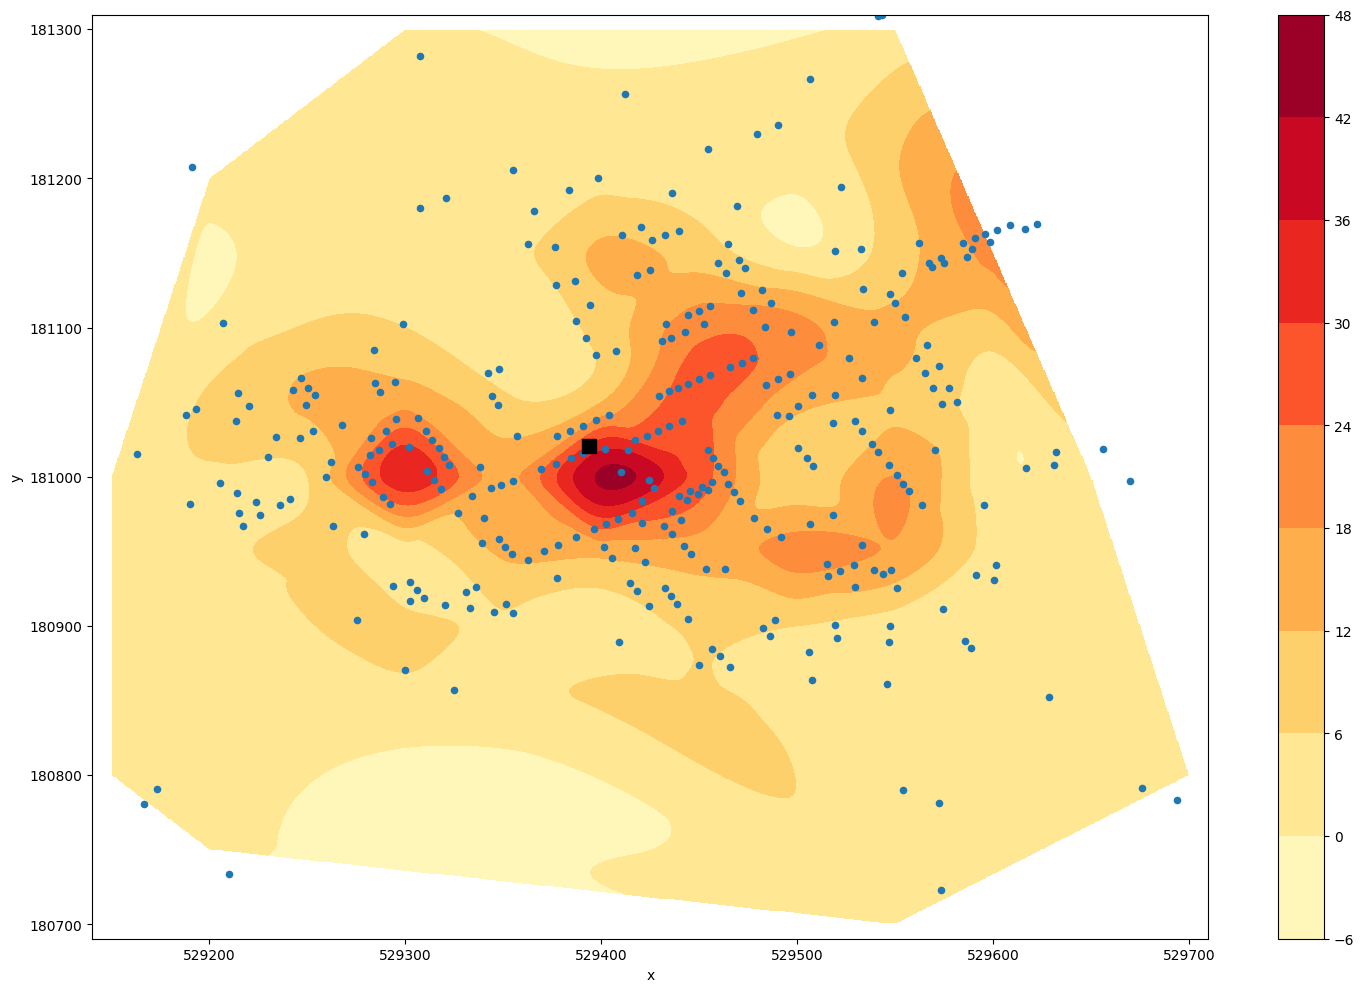

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 12))
i = ax.contourf(surface_deaths, cmap='YlOrRd', extent=(xmin, xmax, ymin, ymax), origin='lower')
plt.colorbar(i)
deaths.plot(kind='scatter', x='x', y='y', ax=ax)
# add in the broad street pump location
ax.plot(529393.4988633909, 181020.5778694971, marker='s', markersize=10, color='black')

Given this we can easily see the major hot-spot in our data, which by no coincidence is next to the location of the Broad Street Pump identified by John Snow.

### Exercise: interpolating city pedestrian data

The dataset `/Data/pedestrians_all.csv.xz` has pedestrian traffic counts for the city of Melbourne from July 2021 to Jan 2025.

1. Load it into a DataFrame. How many rows does it have?
2. Group the "eastings" and "northings" values into 50-metre buckets and sum the `pedestriancount` column for each group. Call the resulting dataframe `counts`. Does this have a more manageable number of rows?
3. Create a mesh grid over the eastings and northings.
4. Use SciPy's `griddata()` function to infer the population count over all the points on the grid.
5. Visualize this using Matplotlib's filled-contour function `contourf()`.
6. Do you think this represents the spatial density of people accurately? Why or why not?

In [9]:
ped = pd.read_csv('/Data/pedestrians_all.csv.xz')
ped[:3]

,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,latitude,longitude,eastings,northings
0,28,2024-06-16,15,699,922,1621,VAC_T,-37.821299,144.968793,321224,5812068
1,139,2024-02-22,11,27,39,66,Signal1647_T,-37.819599,144.963283,320735,5812246
2,4,2021-07-20,5,18,16,34,Swa123_T,-37.814880,144.966088,320971,5812775


In [10]:
# See solutions/pedestrian_interp_mpl_xy.py

## CRS transformation

The geographic location of the data shown in the above plots is hard to understand. We will now superimpose the data on some web map tiles to help us understand it.

We will start with the London cholera data. Notice that the data has $x$ and $y$ values in a projected system in meters (EPSG:27700, the "British National Grid"). To reconstruct latitudes and longitudes in degrees, we need two steps:

1. Define (or assign) the correct CRS (telling Geopandas "these coordinates are in EPSG:27700, the "British National Grid");
2. Then reproject or 'transform' those coordinates into a different CRS (EPSG:4326 or WGS84) so that the geometry is in latitudes and longitudes.

We can reproject each points from its easting/northing coordinates to WGS84 lat/lon using Geopandas like this:

In [11]:
import geopandas as gpd

# Step 1: define the correct CRS
gdf_cholera = gpd.GeoDataFrame(
    merged_deaths,
    geometry=gpd.points_from_xy(merged_deaths["x_round"], merged_deaths["y_round"]),
    crs="EPSG:27700"  # British National Grid
)
gdf_cholera.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

In [12]:
# Step 2: reproject in EPSG:4326
gdf_cholera_4326 = gdf_cholera.to_crs(epsg=4326)
gdf_cholera_4326['lat'] = gdf_cholera_4326.geometry.y
gdf_cholera_4326['lon'] = gdf_cholera_4326.geometry.x
gdf_cholera_4326[:3]

,x_round,y_round,num_cases,geometry,lat,lon
0,529150,180800,4.0,POINT (-0.1403 51.51137),51.511375,-0.140301
1,529150,181000,1.0,POINT (-0.14023 51.51317),51.513172,-0.140228
2,529200,180750,1.0,POINT (-0.1396 51.51091),51.510914,-0.139599


## Superimposing densities on a map

Now that we have latitudes and coordinates, perhaps the simplest way to present this data on a map is to use the `density_map()` function in recent versions of Plotly Express:

In [13]:
import plotly.express as px

px.density_map(gdf_cholera_4326, lat='lat', lon='lon', z='num_cases', height=600, zoom=15)

### Exercise: Plot the Melbourne pedestrian count data on a map using Plotly Express.

1. Create a `geopandas.GeoDataFrame` from the `counts` DataFrame, converting the quantized eastings and northings columns to points using `gpd.points_from_xy`. Hint: the correct CRS is EPSG:7855.

2. Convert to EPSG:4326 and extract latitudes and longitudes from the new `.geometry` into new columns in `ped_counts`.

3. Pass the reprojected data into `px.density_map()`. Note: if you pass in the entire pedestrians dataframe (2 million rows), this will probably crash your browser. So pass in the grouped `ped_counts` instead.

4. Investigate `create_hexbin_mapbox()` in `plotly.figure_factory` as an alternative to `px.density_map()`.

### Solution

In [14]:
# See solutions/plotly_pedestrian_counts.py

Note: We are not directly using our interpolated `surface` here. This is harder to do with Plotly Express.

## Interpolating a surface over reprojected coordinates

When you’re creating a gridded interpolation (e.g., for temperature, density, counts, or any other spatial variable), the choice between working in a projected x–y space (meters) versus lat–lon (degrees) comes down to how large an area you’re covering, which interpolation method you use, and the distortion you can tolerate. Here’s how to decide:

#### 1. Recommended

- Choose a local projected CRS for accurate interpolation.
- Perform the interpolation in meters (so distances are correct).
- Reproject the resulting gridded output back to lat–lon (EPSG:4326) for display (e.g. in Plotly or Leaflet).

Option 1 ensures your interpolation is mathematically consistent but still ends up in lat–lon for mapping. It can be more computationally expensive to reproject all the points on a dense grid.

#### 2. (Acceptable for small regions)

- Stay in lat–lon if your region is small enough that you can treat degrees as “close to linear” over the area.
- Interpolate directly in degrees.
- Plot in lat–lon, no reproject needed.

Option 2 can be simpler but can produce inaccuracies if your area isn’t small or near the equator.

Here we demonstrate option 2:

In [1]:
import numpy as np

lonmax, latmax = gdf_cholera_4326[['lon', 'lat']].max() + 10**-5
lonmin, latmin = gdf_cholera_4326[['lon', 'lat']].min() - 10**-5

# Again interpolate over a square grid of 1000 cells by 1000 cells:
grid_lon, grid_lat = np.meshgrid(np.linspace(lonmin, lonmax, 1000), np.linspace(latmin, latmax, 1000))

# and interpolate the data to the locations from the meshgrid:

from scipy.interpolate import griddata

surface_deaths = griddata(
    gdf_cholera_4326[['lon', 'lat']].values,  # pass in just the numpy arrays
    gdf_cholera_4326['num_cases'].values,
    (grid_lon, grid_lat),
    method='cubic'  # nearest, linear, or cubic
)

NameError: name 'gdf_cholera_4326' is not defined

In [16]:
gdf_cholera_grid = gpd.GeoDataFrame(
    {'density': surface_deaths.ravel()},
    geometry=gpd.points_from_xy(grid_lon.ravel(), grid_lat.ravel(), crs='EPSG:4326')
)

gdf_cholera_grid.sample(3)

,density,geometry
591471,10.408925,POINT (-0.13657 51.51361)
131834,1.266501,POINT (-0.13368 51.51109)
153048,2.318996,POINT (-0.13993 51.51121)


In [17]:
gdf_cholera_4326[:3]

,x_round,y_round,num_cases,geometry,lat,lon
0,529150,180800,4.0,POINT (-0.1403 51.51137),51.511375,-0.140301
1,529150,181000,1.0,POINT (-0.14023 51.51317),51.513172,-0.140228
2,529200,180750,1.0,POINT (-0.1396 51.51091),51.510914,-0.139599


### Using Matplotlib and Contextily

Previously we used Matplotlib to construct a static plot. We can also add map tiles to a Matplotlib plot using the [contextily](https://github.com/geopandas/contextily) package.

Here we use Matplotlib and Contextily to plot a map of London along with the original death locations and the source of the infection (the Broad Street pump):

In [18]:
from shapely.geometry import Point
from pyproj import Transformer

# Source of infection:
broad_street_pump = Point(529393.4988633909, 181020.5778694971)
tr = Transformer.from_crs('EPSG:27700', 'EPSG:4326', always_xy=True)
broad_street_pump_lonlat = tr.transform(broad_street_pump.x, broad_street_pump.y)
broad_street_pump_lonlat

(-0.1367132719363077, 51.51330149939946)

In [19]:
!pip install contextily

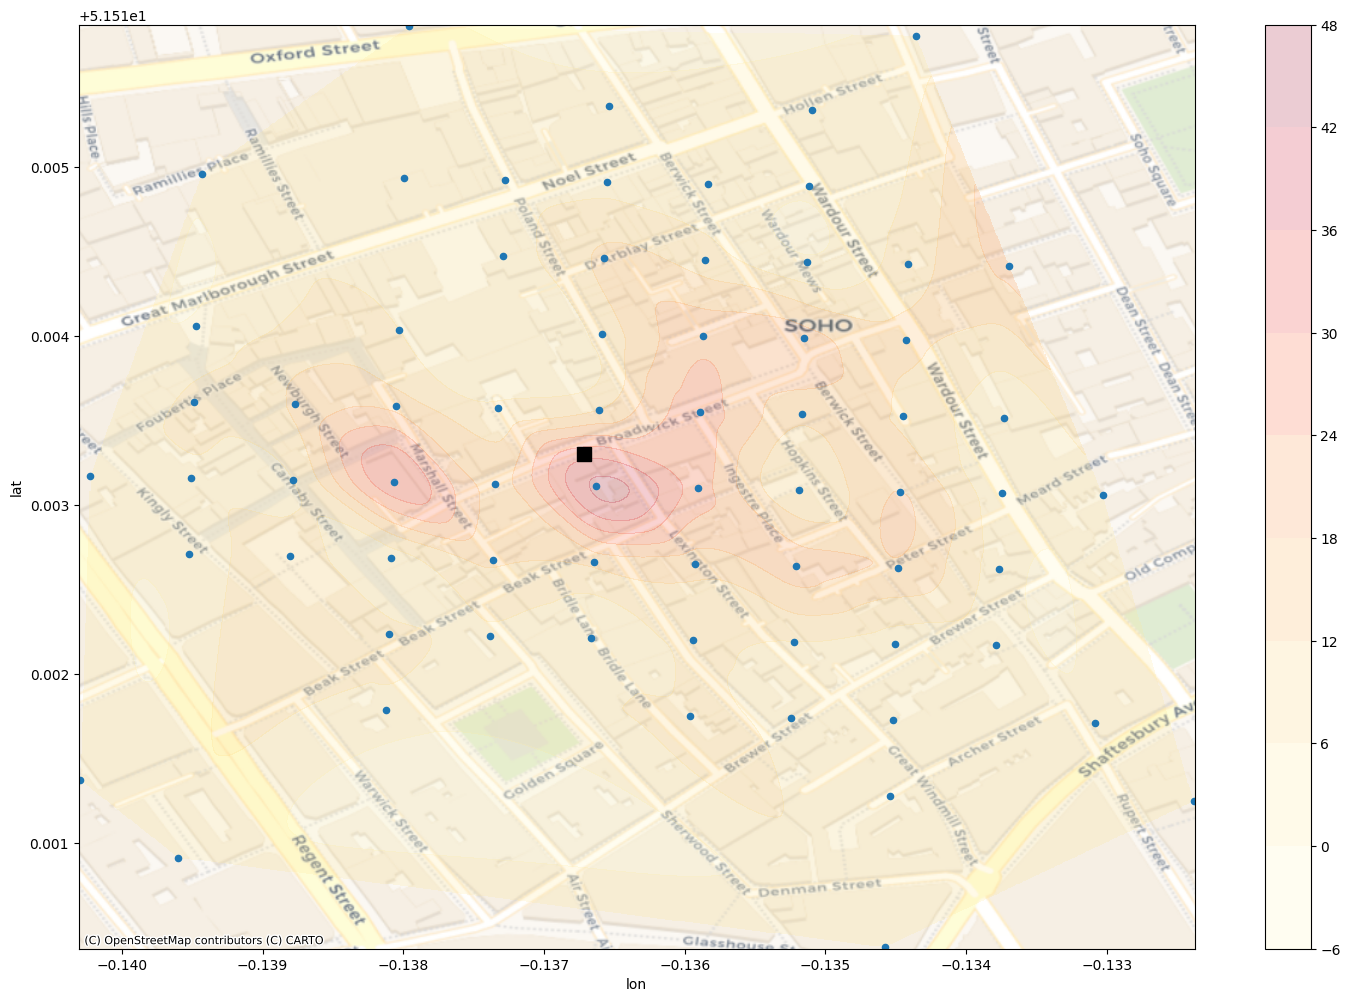

In [20]:
import contextily as cx

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 12))
i = ax.contourf(surface_deaths, cmap='YlOrRd', extent=(lonmin, lonmax, latmin, latmax), origin='lower', alpha=0.2)
plt.colorbar(i)
gdf_cholera_4326.plot(kind='scatter', x='lon', y='lat', ax=ax)
# add in the broad street pump location
ax.plot(*broad_street_pump_lonlat, marker='s', markersize=10, color='black')

cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.CartoDB.Voyager)

### Exercise

Use Matplotlib and Contextily to plot the interpolated pedestrian counts in the Melbourne pedestrian traffic data.

### Solution

In [21]:
# See solutions/map_interp_pedestrians.py

### Extended exercises

1. Split the pedestrians data into weekday vs weekend.
1. Create a plot for each group and compare them.

## Spatial regression with scikit-learn

We now give an example of regression on spatial data using *scikit-learn*. Scikit-learn is a package for machine learning, with high-quality implementations of "classical" ML algorithms including nonlinear regression, classification, and clustering.

You can technically apply any regression algorithm to fit a model mapping coordinates to a value, then evaluate ("predict") the model at grid points to create a spatially gridded surface. However, there are a few pitfalls to consider:

1. Some ML regressors assume your sample points are independent and identically distributed (IID)
2. Spatial data often exhibit autocorrelation ("near things are most related than distant things"). A typical regressor won't account for this.

Here is an example of how we can apply nonlinear regression to our London cholera dataset:

In [22]:
X = gdf_cholera_4326[['lon', 'lat']].values
y = gdf_cholera_4326['num_cases'].values

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
model_deaths = GaussianNB()
model_deaths.fit(X, y)

GaussianNB()

Having fit a regression model, we can now use it to predict the counts on a grid of points. As before, we use `np.meshgrid()` to create `grid_lon` and `grid_lat`, but now we also arrange these into two columns:

In [24]:
import numpy as np

lonmax, latmax = gdf_cholera_4326[['lon', 'lat']].max() + 10**-5
lonmin, latmin = gdf_cholera_4326[['lon', 'lat']].min() - 10**-5

In [25]:
# Again interpolate over a square grid of 1000 cells by 1000 cells:
grid_lon, grid_lat = np.meshgrid(np.linspace(lonmin, lonmax, 1000), np.linspace(latmin, latmax, 1000))

In [26]:
grid_points = np.column_stack([grid_lon.ravel(), grid_lat.ravel()])
grid_points.shape

(1000000, 2)

In [27]:
Z_pred = model_deaths.predict(grid_points)
Z_pred_2d = Z_pred.reshape(grid_lon.shape)

In [28]:
Z_pred_2d.shape

(1000, 1000)

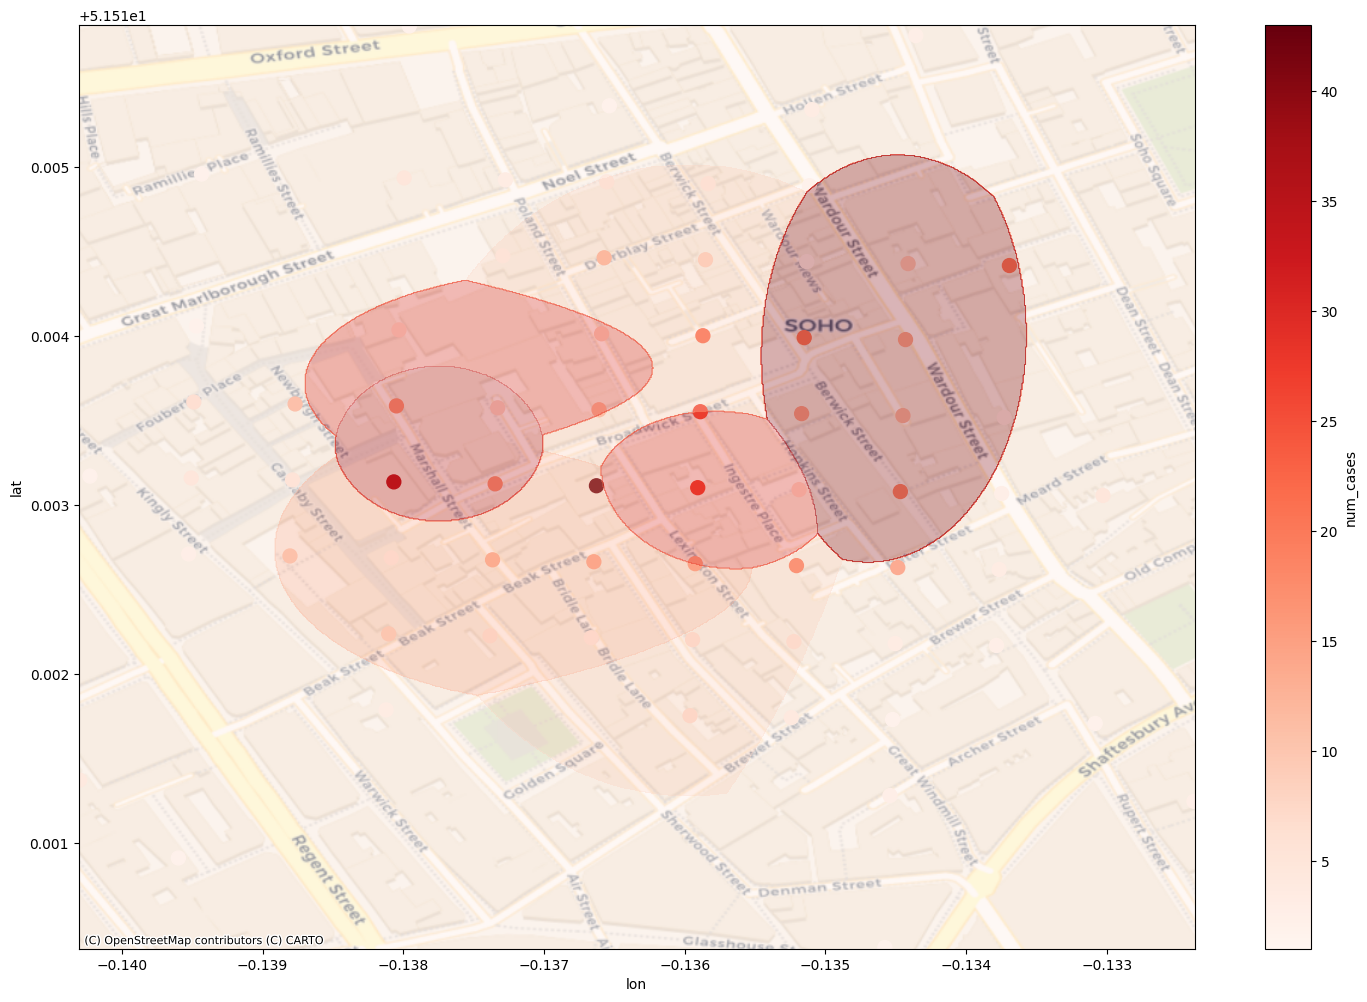

In [29]:
fig, ax = plt.subplots(figsize=(18, 12))
ax = gdf_cholera_4326.plot(c='num_cases', kind='scatter', x='lon', y='lat', ax=ax, s=100, cmap='Reds')
i = ax.contourf(Z_pred_2d, cmap='Reds', extent=(lonmin, lonmax, latmin, latmax), origin='lower', alpha=0.3)
cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.CartoDB.Voyager)

### Exercise: other regression models

1. Try swapping `GaussianNB` for various other regression models, such as the others we imported above:
    - `sklearn.linear_model.LinearRegression`
    - `sklearn.ensemble.RandomForestRegressor`

Which looks the best?

### Exercise: spatial regression 

1. Fit a `GaussianNB` regression model to the Melbourne pedestrian counts data, using latitude and longitude as inputs.
2. Use the fitted model to predict the pedestrian counts for a grid of points over Melbourne (using the min and max of the latitude and longitude columns).
3. Visualize it.

### Solution

In [30]:
# See solutions/spatial_regression_pedestrians.py

## Plotting interpolated data with Bokeh

Bokeh is another powerful library for static and interactive visualization in Python. It is more verbose than Plotly but has better support than Plotly for some tasks, such as visualizing a heat map on a tiled map.

This example shows how to superimpose a heat map on a tiled map using Bokeh.

In [31]:
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import LinearColorMapper

# ---------------------------------------------------------------------------
# 1. CONVERT THE GRID TO WEB MERCATOR
#    Because Bokeh tile providers expect x_range, y_range in meters (EPSG:3857).
# ---------------------------------------------------------------------------
gdf_cholera_grid_wm = gdf_cholera_grid.to_crs("EPSG:3857")

# Convert the corner coordinates first
tr = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x_min, y_max = tr.transform(lonmin, latmax)  # top-left
x_max, y_min = tr.transform(lonmax, latmin)  # bottom-right

Z = surface_deaths
# We have a 2D array Z arranged as [lat rows, lon columns].
# Bokeh's image() assumes the first row in the array is the top row in the plot
# coordinate system. That's consistent if we transform lat in descending order
# or if we "flip" the array. We'll do the simpler approach: just flip the array
# so that row 0 matches top in the final image.
Z_flipped = np.flipud(Z)

# ---------------------------------------------------------------------------
# 2. BUILD A BOKEH FIGURE WITH A WEB MERCATOR TILE BACKGROUND
# ---------------------------------------------------------------------------
p = figure(
    x_range=(x_min, x_max),
    y_range=(y_min, y_max),
    x_axis_type="mercator",
    y_axis_type="mercator",
    width=800,
    height=600,
    title="Interpolated Density (Raster) Over London",
    tools="pan,wheel_zoom,reset"
)

p.add_tile('CartoDB Positron', retina=True)  # or "OSM", "STAMEN_TERRAIN", etc.

# Define a color mapper for Z values
z_min, z_max = np.nanmin(Z_flipped), np.nanmax(Z_flipped)
color_mapper = LinearColorMapper(palette="Viridis256", low=z_min, high=z_max)

# ---------------------------------------------------------------------------
# 3. DRAW THE INTERPOLATED GRID AS A RASTER (p.image)
# ---------------------------------------------------------------------------
# Bokeh's image glyph arguments:
#  - image=[2D_array]
#  - x, y = lower-left corner of the image in map coords
#  - dw, dh = width/height in same coords
p.image(
    image=[Z_flipped],
    x=x_min,         # left
    y=y_min,         # bottom
    dw=(x_max - x_min),  # total width
    dh=(y_max - y_min),  # total height
    color_mapper=color_mapper,
    level="image",
    alpha=0.2
)

# Optional: add a color bar
from bokeh.models import ColorBar
color_bar = ColorBar(color_mapper=color_mapper, label_standoff=12, width=8)
p.add_layout(color_bar, 'right')

# show(p)
output_file("london_cholera_bokeh.html")
save(p)

'/home/jovyan/london_cholera_bokeh.html'